#Домашнє завдання
Сьогодні ви виконаєте завдання зі спектральної кластеризації на наборі даних Iris. Ви будете завантажувати дані, виконувати їхній аналіз, проводити спектральну кластеризацію та оцінювати результати за допомогою Confusion Matrix.

Це допоможе вам закріпити такі навички:

- Робота з бібліотекою sklearn для завантаження та обробки даних
- Використання seaborn для візуалізації розподілу даних за класами
- Застосування методів стандартизації даних для підготовки їх до кластеризації
- Розуміння та експериментування з параметрами спектральної кластеризації
- Оцінка результатів за допомогою Confusion Matrix та візуалізації кластеризації

##Завдання (крок за кроком)


1. **Завантажити та створити DataFrame:** Використовуйте бібліотеку `pandas` для створення та роботи з DataFrame. Дані можна завантажити за допомогою `load_iris()` з бібліотеки `sklearn`.

2. **Отримати базові статистичні характеристики:**
Використовуйте функції `describe()` з бібліотеки `pandas` для отримання статистичних характеристик.

3. **Візуалізувати розподілення спостережень за класами.:** Використовуйте бібліотеку `seaborn` для побудови графіків.

4. **Виконати стандартизацію даних:** Використовуйте бібліотеку `sklearn.preprocessing` для стандартизації даних.

5. **Виконати спектральну кластеризація:** Використовуйте бібліотеку `sklearn.cluster` для виконання спектральної кластеризації.

6. **Порівняти спрогнозовані кластери та дійсні класи:** Використовуйте функцію `confusion_matrix()` з бібліотеки `sklearn.metrics` для отримання результатів.

7. **Візуалізувати результати кластеризації:** Використовуйте бібліотеку `seaborn` або інші засоби візуалізації для відображення результатів.

8. **Висновок:** Використовуйте середовище Jupyter Notebook або іншу платформу для написання текстових висновків та аналізу результатів.

### **Підказки**

Переконайтеся, що у вас встановлені необхідні бібліотеки за допомогою `pip install pandas seaborn scikit-learn`.

### **Формат здачі**

- Посилання на Google Colab

### **Критерії прийому завдання**

- Усі вказані етапи виконані
- До Colab додані висновки.

### **Формат оцінювання**

- Залiк / Незалiк

##Приклад

Методи генерації синтетичних даних

https://scikit-learn.org/stable/datasets/sample_generators.html


Порівняння різних методів кластеризації

https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html

In [2]:
from sklearn.datasets import make_moons
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
%matplotlib inline


Генерація синтетичних даних.
Створюємо дані з 2 класами, які мають форму півмісяців


In [3]:
X, y = make_moons(n_samples=500, noise=0.07, random_state=42)

df = pd.DataFrame(X, columns=["x1", "x2"])
df['true_label'] = y



In [4]:
df.head()

,x1,x2,true_label
0,0.830622,-0.432614,1
1,0.740349,0.825196,0
2,1.033435,-0.489607,1
3,-0.293316,0.964066,0
4,0.308208,1.093364,0


Статистичні характеристики

In [5]:
print("Статистика:")
print(df.describe())

Статистика:
               x1          x2  true_label
count  500.000000  500.000000  500.000000
mean     0.506351    0.251878    0.500000
std      0.871766    0.501909    0.500501
min     -1.131984   -0.653358    0.000000
25%     -0.036730   -0.209559    0.000000
50%      0.473618    0.261045    0.500000
75%      1.057580    0.695747    1.000000
max      2.117060    1.164108    1.000000


Візуалізація розподілу за класами

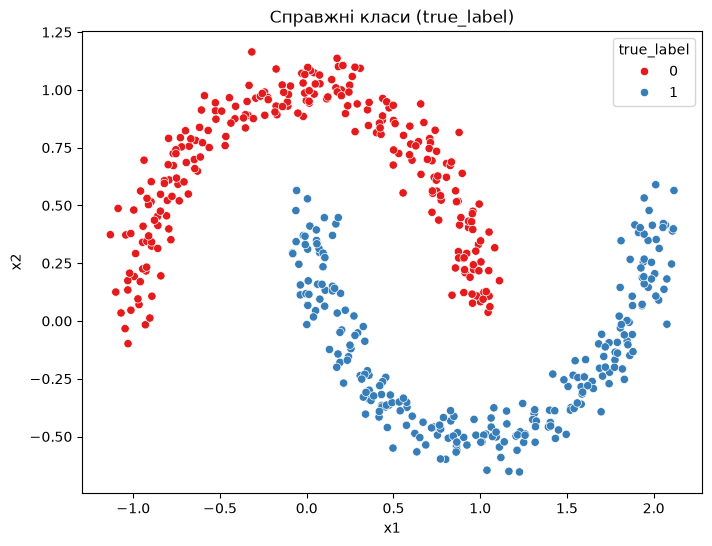

In [6]:

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="x1", y="x2", hue="true_label", palette="Set1")
plt.title("Справжні класи (true_label)")
plt.show()


Стандартизація

In [7]:
scaler = StandardScaler()
X_scaled = scaler.set_output(transform='pandas').fit_transform(X)
X_scaled.describe()

,x0,x1
count,5.000000e+02,5.000000e+02
mean,-2.842171e-17,-2.700062e-16
std,1.001002e+00,1.001002e+00
min,-1.881210e+00,-1.805392e+00
25%,-6.235898e-01,-9.202859e-01
50%,-3.758526e-02,1.828131e-02
75%,6.329463e-01,8.852454e-01
max,1.849489e+00,1.819339e+00


Спектральна кластеризація

In [8]:

spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
predicted_labels = spectral.fit_predict(X_scaled)


C:\Users\iermo\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Додаємо результат до датафрейму

In [9]:
df["predicted_label"] = predicted_labels
df.head()

,x1,x2,true_label,predicted_label
0,0.830622,-0.432614,1,0
1,0.740349,0.825196,0,1
2,1.033435,-0.489607,1,0
3,-0.293316,0.964066,0,1
4,0.308208,1.093364,0,1


Порівняння кластерів з істинними класами

In [10]:
cm = confusion_matrix(df["true_label"], df["predicted_label"])
print("Матриця невідповідностей (confusion matrix):")
print(cm)


Матриця невідповідностей (confusion matrix):
[[  0 250]
 [250   0]]


Візуалізація матриці

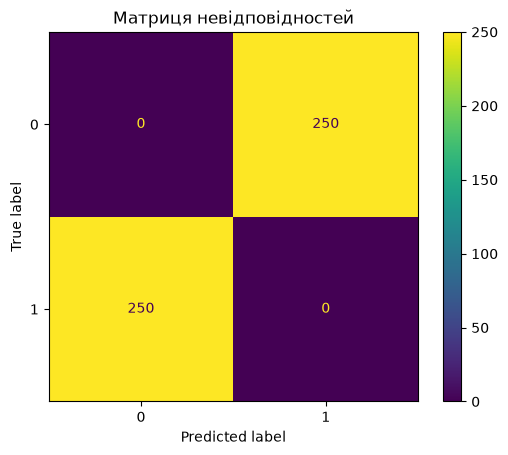

In [11]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Матриця невідповідностей")
plt.show()


Візуалізація кластерів


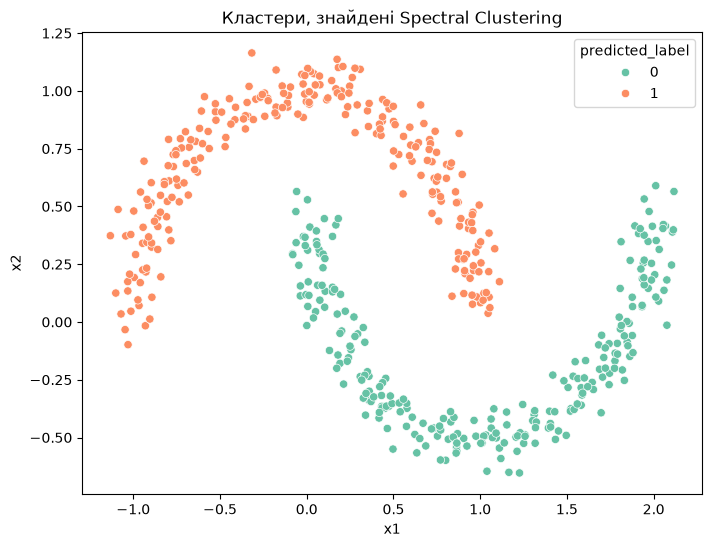

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="x1", y="x2", hue="predicted_label", palette="Set2")
plt.title("Кластери, знайдені Spectral Clustering")
plt.show()


## Домашнє завдання: Спектральна кластеризація на наборі даних Iris

### 1. Завантаження даних та створення DataFrame

In [13]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["target"] = iris.target
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 2. Базові статистичні характеристики

In [14]:
print("Статистика:")
print(iris_df.describe())

Статистика:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


### 3. Візуалізація розподілу спостережень за класами

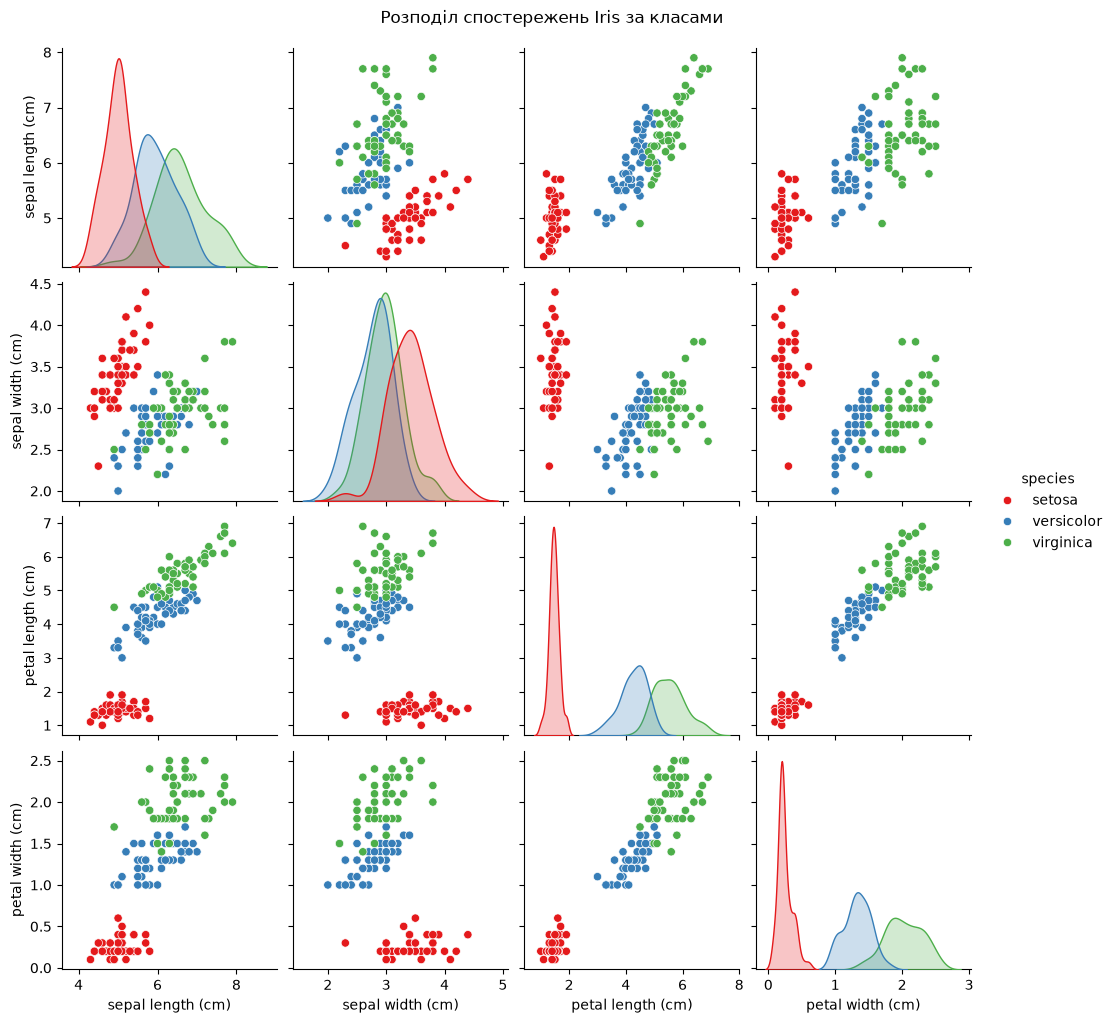

In [15]:
sns.pairplot(iris_df, vars=iris.feature_names, hue="species", palette="Set1")
plt.suptitle("Розподіл спостережень Iris за класами", y=1.02)
plt.show()

### 4. Стандартизація даних

In [16]:
iris_scaler = StandardScaler()
X_iris_scaled = iris_scaler.set_output(transform="pandas").fit_transform(iris_df[iris.feature_names])
X_iris_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


### 5. Спектральна кластеризація

In [17]:
iris_spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    assign_labels="kmeans",
    random_state=42,
)
iris_predicted_labels = iris_spectral.fit_predict(X_iris_scaled)

iris_df["predicted_cluster"] = iris_predicted_labels
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,predicted_cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


### 6. Порівняння спрогнозованих кластерів та дійсних класів

Мітки кластерів, знайдені алгоритмом кластеризації, є довільними (кластер `0` не обов'язково відповідає класу `0`). Щоб побудувати змістовну Confusion Matrix, спочатку узгодимо номери кластерів із дійсними класами за допомогою угорського алгоритму (`linear_sum_assignment`), що максимізує суму елементів на головній діагоналі.

In [18]:
from scipy.optimize import linear_sum_assignment

raw_cm = confusion_matrix(iris_df["target"], iris_df["predicted_cluster"])

row_ind, col_ind = linear_sum_assignment(-raw_cm)
cluster_to_class = dict(zip(col_ind, row_ind))
iris_df["predicted_label"] = iris_df["predicted_cluster"].map(cluster_to_class)

cm = confusion_matrix(iris_df["target"], iris_df["predicted_label"])
accuracy = (iris_df["target"] == iris_df["predicted_label"]).mean()

print("Матриця невідповідностей (confusion matrix) після узгодження міток:")
print(cm)
print(f"\nТочність кластеризації (accuracy): {accuracy:.2%}")

Матриця невідповідностей (confusion matrix) після узгодження міток:
[[49  1  0]
 [ 0 47  3]
 [ 0 18 32]]

Точність кластеризації (accuracy): 85.33%


### 7. Візуалізація матриці невідповідностей

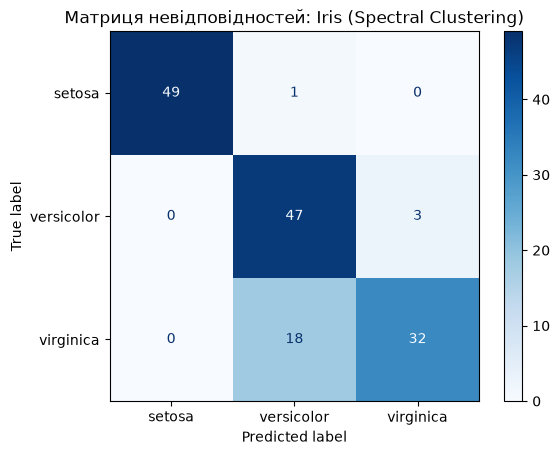

In [19]:
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names).plot(cmap="Blues")
plt.title("Матриця невідповідностей: Iris (Spectral Clustering)")
plt.show()

### 8. Візуалізація результатів кластеризації

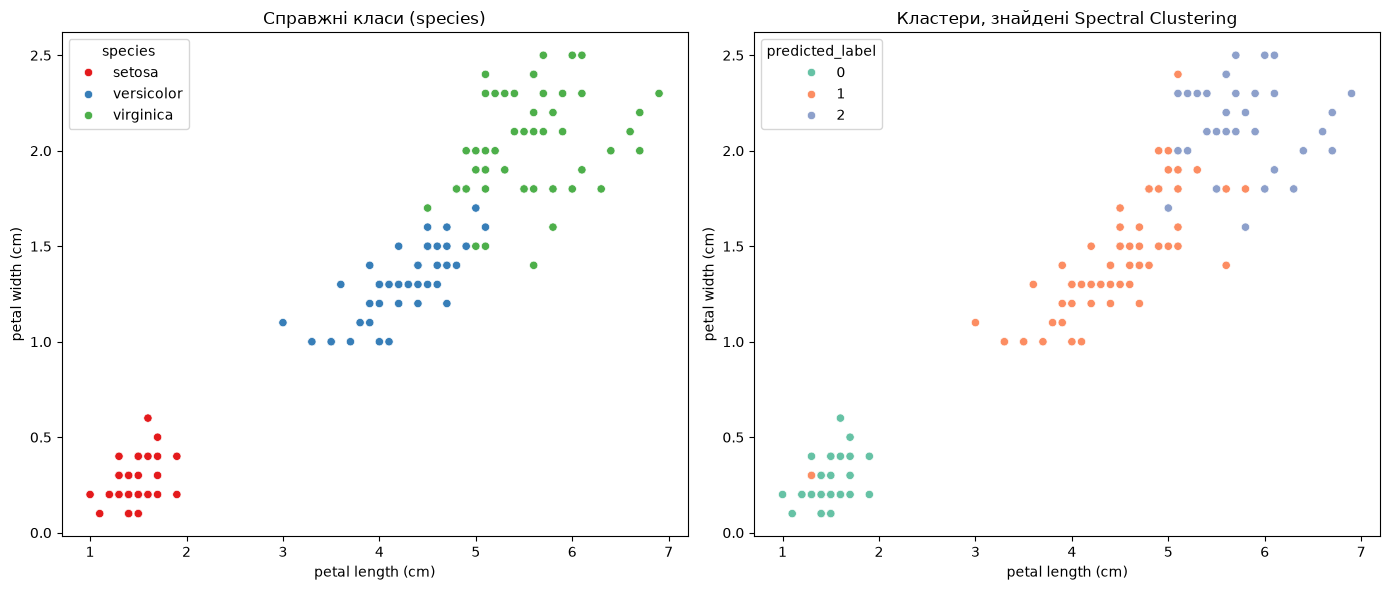

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=iris_df, x="petal length (cm)", y="petal width (cm)",
    hue="species", palette="Set1", ax=axes[0],
)
axes[0].set_title("Справжні класи (species)")

sns.scatterplot(
    data=iris_df, x="petal length (cm)", y="petal width (cm)",
    hue="predicted_label", palette="Set2", ax=axes[1],
)
axes[1].set_title("Кластери, знайдені Spectral Clustering")

plt.tight_layout()
plt.show()

### Висновок

- Спектральна кластеризація з `affinity='nearest_neighbors'` та `n_clusters=3` на стандартизованих даних Iris дала точність (accuracy) **85.33%** після узгодження номерів кластерів із дійсними класами.
- Клас `setosa` відокремлюється від інших майже ідеально (49 з 50 спостережень визначені правильно), оскільки він добре відділений від `versicolor` та `virginica` навіть по одній ознаці (наприклад, довжині пелюстки).
- Основні помилки кластеризації виникають на межі класів `versicolor` і `virginica`: 18 спостережень `virginica` потрапили до кластера `versicolor`, оскільки ці два види мають істотне перекриття значень довжини та ширини пелюстки.
- Порівняно з прикладом на `make_moons` (де класи мали форму півмісяців і метод впорався з ними ідеально), на Iris результат дещо гірший — межа між versicolor і virginica є розмитою навіть для справжніх класів, тому жоден метод кластеризації не зможе розділити їх бездоганно.
- Оскільки мітки кластерів, які повертає алгоритм, довільні (номер кластера не обов'язково збігається з номером класу), для коректного порівняння з дійсними класами їх було узгоджено за допомогою угорського алгоритму (`linear_sum_assignment`) — без цього кроку Confusion Matrix виглядала б так, ніби модель помиляється набагато частіше, хоча насправді вона просто по-іншому пронумерувала кластери.
- Загалом спектральна кластеризація підтвердила, що вона є ефективним методом для набору даних Iris і дає результат, доволі близький до справжнього розподілу на види, особливо з урахуванням того, що це неконтрольоване навчання (алгоритм не мав доступу до дійсних міток під час кластеризації).